# Eksperyment: Wpływ funkcji straty na wyniki MLP

W tym notatniku zbadamy wpływ funkcji straty na proces uczenia modelu MLP.

Dla zadania klasyfikacji porównamy dwie funkcje straty: entropię krzyżową (cross-entropy) oraz błąd średniokwadratowy (MSE). Dla zadania regresji porównujemy MSE oraz MAE (Mean Absolute Error).

In [9]:
# from mlp.mlp import MLP
# from mlp.utils import plot_accuracy
# import inspect
#
# # print(inspect.getsource(plot_accuracy))
# print(inspect.getsource(MLP.__init__))

In [10]:
import numpy as np
from mlp.mlp import MLP
from mlp.utils import (
    load_dataset, plot_dataset, plot_loss,
    plot_decision_boundary, plot_accuracy, plot_weights_together
)

In [24]:
# === 1. Konfiguracja ===

# Wybierz zadanie i plik danych:
# przykład: "lab1_data/Classification/data.simple.train.1000.csv"
data_path = "../lab1_data/Classification/data.simple.train.100.csv"
task = "binary"          # "binary", "multiclass", "regression"
activation = "gelu"      # "sigmoid", "gelu", "identity"
losses = ["mse", "binary_cross_entropy"]  # zależnie od zadania
epochs = 1000
learning_rate = 0.01

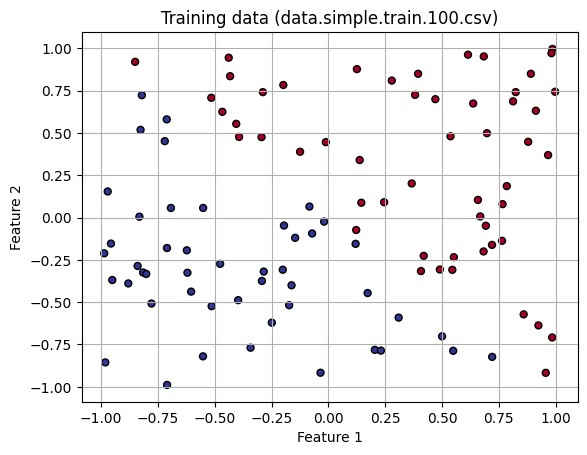

In [25]:
X, y = load_dataset(data_path)
plot_dataset(X, y, title=f"Training data ({data_path.split('/')[-1]})")


=== Training with loss: mse ===
epoch=   0  loss=0.29267458  lr=0.01
epoch= 100  loss=0.14246809  lr=0.01
epoch= 200  loss=0.09365552  lr=0.01
epoch= 300  loss=0.07167746  lr=0.01
epoch= 400  loss=0.05921110  lr=0.01
epoch= 500  loss=0.05105637  lr=0.01
epoch= 600  loss=0.04520465  lr=0.01
epoch= 700  loss=0.04072986  lr=0.01
epoch= 800  loss=0.03715074  lr=0.01
epoch= 900  loss=0.03419441  lr=0.01


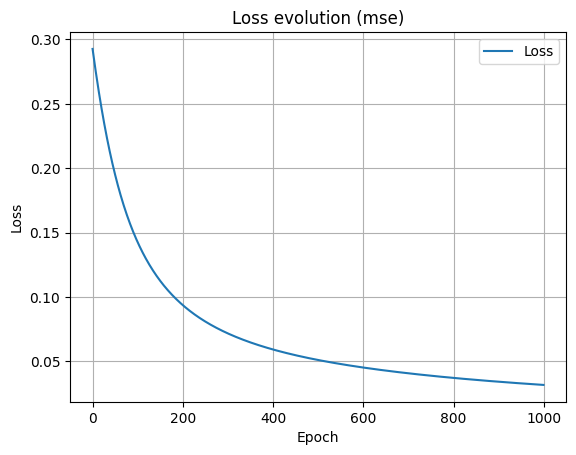


=== Porównanie predykcji vs prawdziwe etykiety ===
  0: pred = 0, true = 0, equal = True
  1: pred = 1, true = 1, equal = True
  2: pred = 0, true = 0, equal = True
  3: pred = 0, true = 0, equal = True
  4: pred = 0, true = 0, equal = True
  5: pred = 0, true = 0, equal = True
  6: pred = 1, true = 1, equal = True
  7: pred = 0, true = 0, equal = True
  8: pred = 1, true = 1, equal = True
  9: pred = 0, true = 0, equal = True
 10: pred = 1, true = 1, equal = True
 11: pred = 0, true = 0, equal = True
 12: pred = 0, true = 0, equal = True
 13: pred = 0, true = 0, equal = True
 14: pred = 1, true = 1, equal = True
 15: pred = 1, true = 1, equal = True
 16: pred = 1, true = 1, equal = True
 17: pred = 0, true = 0, equal = True
 18: pred = 0, true = 0, equal = True
 19: pred = 0, true = 0, equal = True
 20: pred = 0, true = 0, equal = True
 21: pred = 0, true = 0, equal = True
 22: pred = 0, true = 0, equal = True
 23: pred = 0, true = 0, equal = True
 24: pred = 0, true = 0, equal = Tru

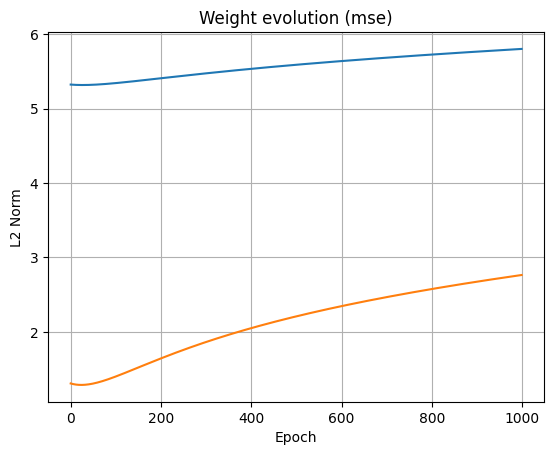

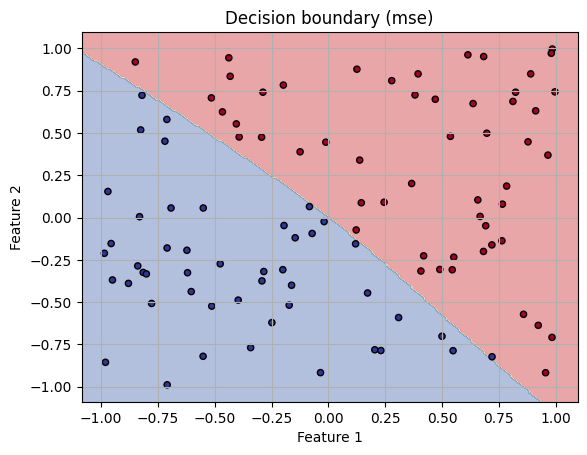


=== Training with loss: binary_cross_entropy ===
epoch=   0  loss=0.78034239  lr=0.01
epoch= 100  loss=0.57783324  lr=0.01
epoch= 200  loss=0.46317992  lr=0.01
epoch= 300  loss=0.38933870  lr=0.01
epoch= 400  loss=0.33785162  lr=0.01
epoch= 500  loss=0.29998045  lr=0.01
epoch= 600  loss=0.27098856  lr=0.01
epoch= 700  loss=0.24807789  lr=0.01
epoch= 800  loss=0.22949472  lr=0.01
epoch= 900  loss=0.21408936  lr=0.01


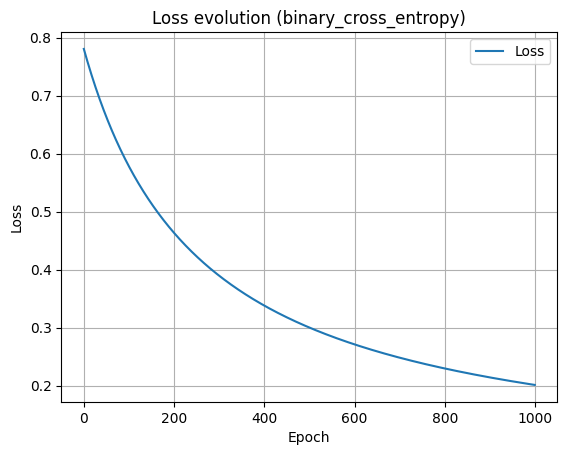


=== Porównanie predykcji vs prawdziwe etykiety ===
  0: pred = 0, true = 0, equal = True
  1: pred = 1, true = 1, equal = True
  2: pred = 0, true = 0, equal = True
  3: pred = 0, true = 0, equal = True
  4: pred = 0, true = 0, equal = True
  5: pred = 0, true = 0, equal = True
  6: pred = 1, true = 1, equal = True
  7: pred = 0, true = 0, equal = True
  8: pred = 1, true = 1, equal = True
  9: pred = 0, true = 0, equal = True
 10: pred = 1, true = 1, equal = True
 11: pred = 0, true = 0, equal = True
 12: pred = 0, true = 0, equal = True
 13: pred = 0, true = 0, equal = True
 14: pred = 1, true = 1, equal = True
 15: pred = 1, true = 1, equal = True
 16: pred = 1, true = 1, equal = True
 17: pred = 0, true = 0, equal = True
 18: pred = 0, true = 0, equal = True
 19: pred = 0, true = 0, equal = True
 20: pred = 0, true = 0, equal = True
 21: pred = 0, true = 0, equal = True
 22: pred = 0, true = 0, equal = True
 23: pred = 0, true = 0, equal = True
 24: pred = 0, true = 0, equal = Tru

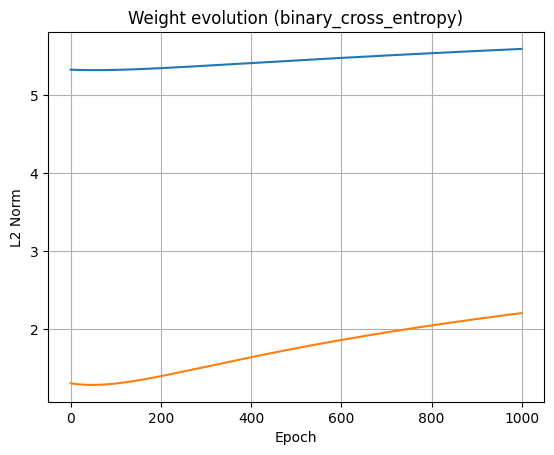

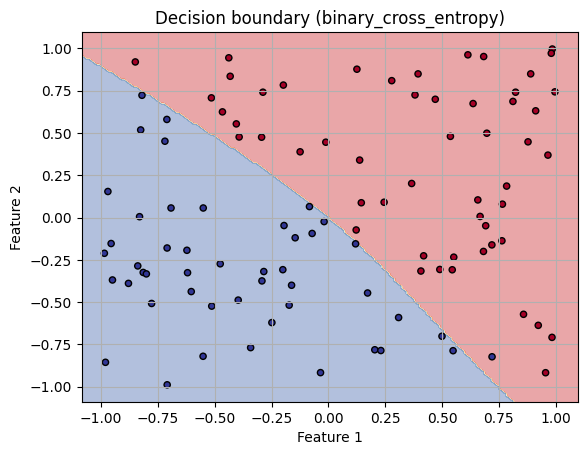

In [27]:
# === 3. Eksperyment z różnymi funkcjami strat ===
results = {}

for loss in losses:
    print(f"\n=== Training with loss: {loss} ===")
    model = MLP(
        layer_sizes=[X.shape[1], 16, (1 if task != "multiclass" else len(np.unique(y)))],
        task=task,
        activation=activation,
        learning_rate=learning_rate,
        loss=loss,
        seed=42
    )

    history, weight_history = model.fit(X, y, epochs=epochs, verbose=True)
    results[loss] = {"model": model, "loss_history": history, "weight_history": weight_history}

    # --- Wizualizacje ---
    plot_loss(history, title=f"Loss evolution ({loss})")
    if task in ["binary", "multiclass"]:
        preds = model.predict(X)
        acc = np.mean(preds.ravel() == y.ravel())   # <== użyj ravel() po obu stronach
        # print(f"preds: {preds.ravel()}")
        # print(f"y: {y.ravel()}")
        # print(f"preds == y: {preds == y}")
        # print(f"preds[0]: {preds[0]}")
        # print(f"y[0]: {y[0]}")
        # print(f"preds[0] == y[0]: {preds[0] == y[0]}")
        # print(f"preds[1]: {preds[1]}")
        # print(f"y[1]: {y[1]}")
        # print(f"preds[1] == y[1]: {preds[1] == y[1]}")

        print("\n=== Porównanie predykcji vs prawdziwe etykiety ===")
        for i, (p, t) in enumerate(zip(preds.ravel(), y.ravel())):
            print(f"{i:3d}: pred = {int(p)}, true = {int(t)}, equal = {p == t}")

        print(f"Final accuracy ({loss}): {acc:.4f}")
    plot_weights_together(weight_history, title=f"Weight evolution ({loss})")

    if task != "regression":
        plot_decision_boundary(model, X, y, title=f"Decision boundary ({loss})")

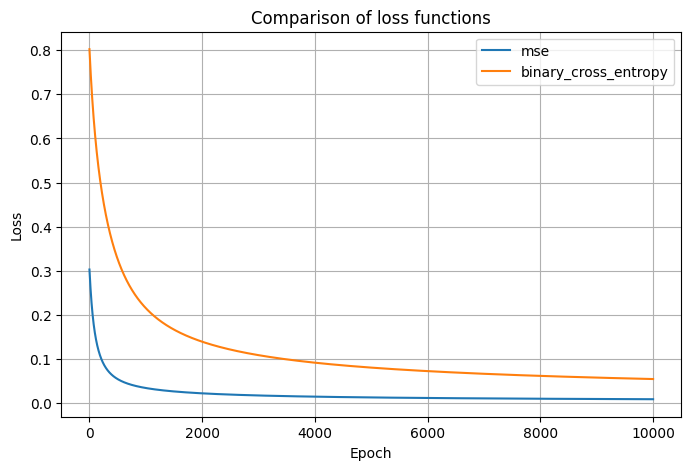

In [14]:
# === 4. Porównanie funkcji straty ===
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for loss, res in results.items():
    plt.plot(res["loss_history"], label=loss)
plt.title("Comparison of loss functions")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()